<a href="https://colab.research.google.com/github/Matej-Vylet/MPA-MLF/blob/main/mlf_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of training images: 9227
Train CSV columns: ['id', 'target']
   id  label
0   0      0
1   1      1
2   2      0
3   3      2
4   4      2
X shape: (9227, 64, 64, 1)
y shape: (9227,)
X_train shape: (7381, 64, 64, 1)
X_val shape: (1846, 64, 64, 1)
y_train shape: (7381, 4)
y_val shape: (1846, 4)
Classes: [0 1 2 3]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,092 (6.20 MB)

 Trainable params: 1,625,092 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.4307 - loss: 1.2691 - val_accuracy: 0.5466 - val_loss: 0.9564 - learning_rate: 0.0050
Epoch 2/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6606 - loss: 0.8017 - val_accuracy: 0.7887 - val_loss: 0.5481 - learning_rate: 0.0050
Epoch 3/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7553 - loss: 0.5854 - val_accuracy: 0.8407 - val_loss: 0.4251 - learning_rate: 0.0050
Epoch 4/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7961 - loss: 0.4961 - val_accuracy: 0.8575 - val_loss: 0.3737 - learning_rate: 0.0050
Epoch 5/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8213 - loss: 0.4461 - val_accuracy: 0.8689 - val_loss: 0.3491 - learning_rate: 0.0050
Epoch 6/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8336 - loss: 0.4128 - val_accuracy: 0.8846 - val_loss: 0.3213 - learning_rate: 0.0050
Epoch 7/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8449 - loss

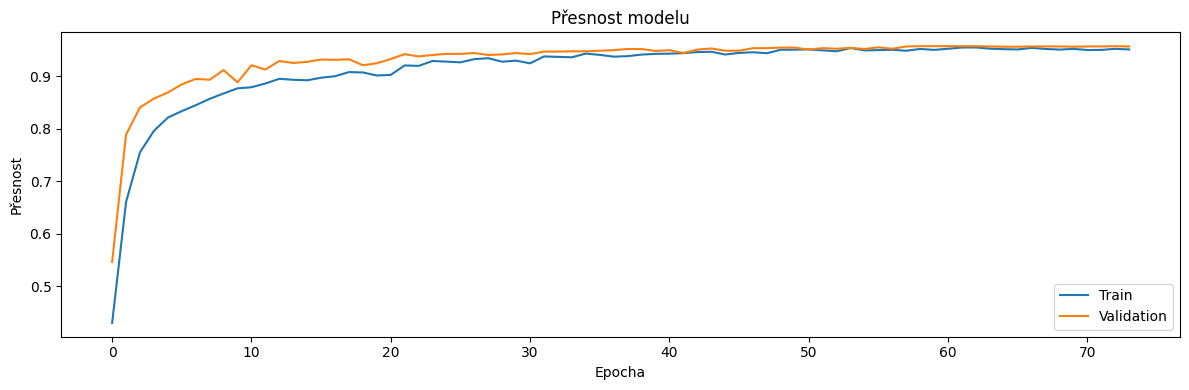

In [ ]:


import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical
from keras.optimizers import Adam
from keras.optimizers import AdamW
from keras.optimizers import SGD

drive.mount('/content/drive')
base = '/content/drive/MyDrive/MLF_project'

TRAIN_DIR = f'{base}/x_train'
TEST_DIR = f'{base}/x_test'
TRAIN_CSV = f'{base}/y_train_v2.csv'
SAMPLE_SUBMISSION_CSV = f'{base}/y_test_submission_example_v2.csv'

def load_grayscale_image(image_path, target_size=(51, 45)):
    im = Image.open(image_path).convert('L')
    im = im.resize(target_size)
    im = np.array(im, dtype=np.float32) / 255.0
    return im

def numeric_file_key(path_obj: Path):
    stem = path_obj.stem
    digits = ''.join(ch for ch in stem if ch.isdigit())
    return int(digits) if digits else stem


def find_id_and_label_columns(df: pd.DataFrame):
    lower_cols = [str(c).strip().lower() for c in df.columns]

    id_candidates = ['id', 'image', 'image_id', 'img_id', 'index']
    label_candidates = ['label', 'labels', 'class', 'target', 'y']

    id_col = None
    label_col = None

    for original, lower in zip(df.columns, lower_cols):
        if lower in id_candidates and id_col is None:
            id_col = original
        if lower in label_candidates and label_col is None:
            label_col = original

    if df.shape[1] == 1:
        label_col = df.columns[0]
        id_col = None
    elif df.shape[1] >= 2:
        if id_col is None:
            id_col = df.columns[0]
        if label_col is None:
            label_col = df.columns[1]

    return id_col, label_col


train_df = pd.read_csv(TRAIN_CSV)
train_id_col, train_label_col = find_id_and_label_columns(train_df)

train_image_paths = sorted(Path(TRAIN_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of training images: {len(train_image_paths)}')
print('Train CSV columns:', list(train_df.columns))

if train_id_col is None:
    train_labels_df = pd.DataFrame({
        'id': np.arange(1, len(train_df)),
        'label': train_df[train_label_col].to_numpy()
    })
else:
    train_labels_df = train_df[[train_id_col, train_label_col]].copy()
    train_labels_df.columns = ['id', 'label']

train_labels_df = train_labels_df.sort_values('id').reset_index(drop=True)
train_image_ids = np.array([numeric_file_key(p) for p in train_image_paths])

print(train_labels_df.head())

def build_dataset(image_paths, labels_df=None, target_size=(64, 64)):
    X = []
    y = []
    ids = []

    label_map = None
    if labels_df is not None:
        label_map = dict(zip(labels_df['id'].astype(int), labels_df['label'].astype(int)))

    for img_path in image_paths:
        img_id = int(numeric_file_key(img_path)-1)

        # Skip image if no label exists in label_map
        if label_map is not None and img_id not in label_map:
            continue

        img = load_grayscale_image(img_path, target_size=target_size)
        X.append(img)
        ids.append(img_id)

        if label_map is not None:
            y.append(label_map[img_id])

    X = np.array(X, dtype=np.float32)
    X = X.reshape(-1, target_size[0], target_size[1], 1)
    ids = np.array(ids)

    if label_map is not None:
        y = np.array(y, dtype=np.int32)
        return X, y, ids

    return X, ids


image_size = (64, 64)


X, y, train_ids = build_dataset(train_image_paths, train_labels_df, target_size=image_size)
y_cat = to_categorical(y, 4)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, stratify=y
)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')
print('Classes:', np.unique(y))

model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))



model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

model.summary()

epochs = 120
batch_size = 64

model.compile(optimizer=AdamW(learning_rate=0.005), loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=4, min_lr=1e-7, verbose=1)


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


def numeric_file_key(path_obj: Path):
    stem = path_obj.stem
    digits = ''.join(ch for ch in stem if ch.isdigit())
    return int(digits) if digits else stem


def find_id_and_label_columns(df: pd.DataFrame):
    lower_cols = [str(c).strip().lower() for c in df.columns]

    id_candidates = ['id', 'image', 'image_id', 'img_id', 'index']
    label_candidates = ['label', 'labels', 'class', 'target', 'y']

    id_col = None
    label_col = None

    for original, lower in zip(df.columns, lower_cols):
        if lower in id_candidates and id_col is None:
            id_col = original
        if lower in label_candidates and label_col is None:
            label_col = original

    if df.shape[1] == 1:
        label_col = df.columns[0]
        id_col = None
    elif df.shape[1] >= 2:
        if id_col is None:
            id_col = df.columns[0]
        if label_col is None:
            label_col = df.columns[1]

    return id_col, label_col


train_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
train_id_col, train_label_col = find_id_and_label_columns(train_df)

train_image_paths = sorted(Path(TEST_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of training images: {len(train_image_paths)}')
print('Train CSV columns:', list(train_df.columns))

if train_id_col is None:
    train_labels_df = pd.DataFrame({
        'id': np.arange(1, len(train_df)),
        'label': train_df[train_label_col].to_numpy()
    })
else:
    train_labels_df = train_df[[train_id_col, train_label_col]].copy()
    train_labels_df.columns = ['id', 'label']

train_labels_df = train_labels_df.sort_values('id').reset_index(drop=True)
train_image_ids = np.array([numeric_file_key(p) for p in train_image_paths])

print(train_labels_df.head())

test_image_paths = sorted(Path(TEST_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of test images: {len(test_image_paths)}')

X_test, test_ids = build_dataset(test_image_paths, labels_df=None, target_size=image_size)

print(f'X_test shape: {X_test.shape}')

test_pred_prob = model.predict(X_test)
test_pred = np.argmax(test_pred_prob, axis=1)


submission_df = pd.DataFrame({
    'id': test_ids,
    'target': test_pred
})


submission_df = submission_df.sort_values('id').reset_index(drop=True)

print(submission_df.head())


submission_path = f'{base}/submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f'Submission file saved to {submission_path}')

plt.figure(figsize=(12, 4))



plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Přesnost modelu')
plt.xlabel('Epocha')
plt.ylabel('Přesnost')
plt.legend()

plt.tight_layout()
plt.show()

Validation Loss: 0.1333
Validation Accuracy: 0.9572
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


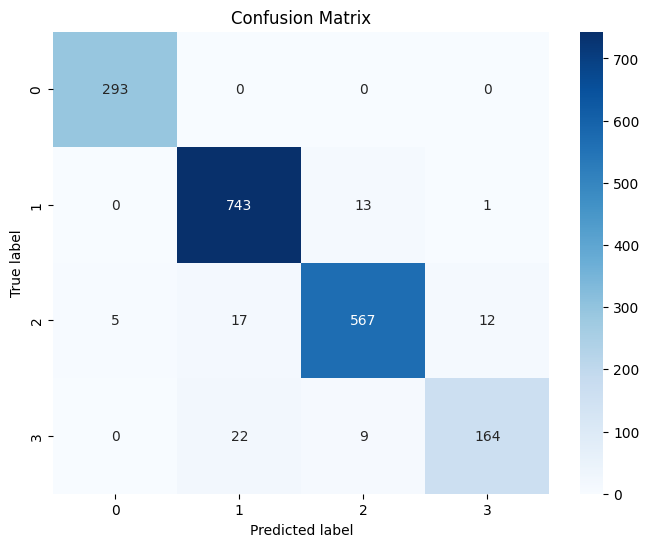

Macro F1 score: 0.9479
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       293
           1       0.95      0.98      0.97       757
           2       0.96      0.94      0.95       601
           3       0.93      0.84      0.88       195

    accuracy                           0.96      1846
   macro avg       0.96      0.94      0.95      1846
weighted avg       0.96      0.96      0.96      1846



In [ ]:

val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

val_pred_prob = model.predict(X_val)
val_pred = np.argmax(val_pred_prob, axis=1)
val_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

macro_f1 = f1_score(val_true, val_pred, average='macro')
print(f'Macro F1 score: {macro_f1:.4f}')
print(classification_report(val_true, val_pred))